Best params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.7832621188643538
R2: 0.77565532402328
MSE: 0.2939832776204393
les meilleur features sont[0.59887303 0.04791043 0.02969533 0.01491939 0.01521383 0.1398617
 0.07675734 0.07676894]


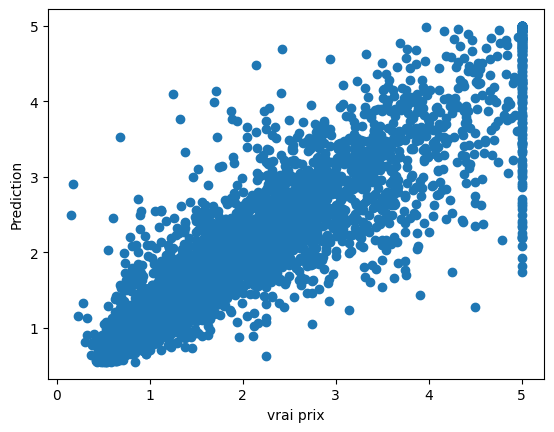

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#==== j'ai pas utilise un pipeline car le model RandomForest n'a gereralement pas besoin d'un preprocessing(StandardScaler)###
model = RandomForestRegressor(random_state=0)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [2, 3]
}

grid = GridSearchCV(model, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

y_pred = best_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print(f"les meilleur features sont{best_model.feature_importances_}")
